In [7]:
# tratamiento de datos
import numpy as np
import pandas as pd

# graficos
import matplotlib.pyplot as plt

# prepocesado y modelado
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA

In [8]:
import numpy as np
import pandas as pd

In [9]:
df = pd.DataFrame(np.array([[7,6.5,9.2,8.6,8],
                            [7.5,9.4,7.3,7,7],
                            [7.6,9.2,8,8,7.5],
                            [5,6.5,6.5,7,9],
                            [6,6,7.8,9.7,3],
                            [7.8,9.6,7.7,8,6.5],
                            [6.3,6.4,8.2,9,7.2],
                            [7.9,9.7,7.5,8,6],
                            [6,6,6.5,5.5,8.7],
                            [6.8,7.2,8.7,9,7]]),
                 index=["Lucia","Pedro","Ines","Luis","Ana","Carlos","Jose","Sonia","Maria","Juan"],
                 columns=["Matematicas","Ciencias","Español","Historia","EdFisica"])

df



,Matematicas,Ciencias,Español,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Ana,6.0,6.0,7.8,9.7,3.0
Carlos,7.8,9.6,7.7,8.0,6.5
Jose,6.3,6.4,8.2,9.0,7.2
Sonia,7.9,9.7,7.5,8.0,6.0
Maria,6.0,6.0,6.5,5.5,8.7
Juan,6.8,7.2,8.7,9.0,7.0


In [10]:
# Det. el numero de renglones de la base de datos
index = df.index
renglones = len(index)
renglones

10

In [11]:
# estandarizacion de las variables
df2 = StandardScaler().fit_transform(df)
df2

array([[ 0.23263076, -0.7529862 ,  1.78848525,  0.53369011,  0.6333689 ],
       [ 0.78651352,  1.14584856, -0.53899555, -0.84357469,  0.00627098],
       [ 0.89729007,  1.01489444,  0.31849737,  0.01721581,  0.31981994],
       [-1.98290027, -0.7529862 , -1.51898747, -0.84357469,  1.26046682],
       [-0.87513476, -1.0803715 ,  0.07349939,  1.48055966, -2.50212069],
       [ 1.11884317,  1.27680268, -0.0489996 ,  0.01721581, -0.30727798],
       [-0.5428051 , -0.81846326,  0.56349535,  0.87800631,  0.13169056],
       [ 1.22961972,  1.34227974, -0.29399757,  0.01721581, -0.62082694],
       [-0.87513476, -1.0803715 , -1.51898747, -2.13476044,  1.07233744],
       [ 0.01107766, -0.29464677,  1.1759903 ,  0.87800631,  0.00627098]])

In [12]:
# Calculo de la matriz de correlaciones para la matriz transformada
A = (1/renglones) * np.dot(df2.T,df2)
A

array([[ 1.        ,  0.85407878,  0.38457424,  0.12949264, -0.19874722],
       [ 0.85407878,  1.        , -0.02005218, -0.09412459, -0.08848544],
       [ 0.38457424, -0.02005218,  1.        ,  0.75689115, -0.22169923],
       [ 0.12949264, -0.09412459,  0.75689115,  1.        , -0.66136287],
       [-0.19874722, -0.08848544, -0.22169923, -0.66136287,  1.        ]])

In [14]:
# Entrenamiento del modelo PCA con el escaldo de los datos
pca_pipe = make_pipeline(StandardScaler(),PCA())
pca_pipe.fit(df)

# se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps["pca"]

print("Eigenvalores:")
results = LA.eigvals(A)
print(results)

Eigenvalores:
[2.31722577 1.72705542 0.00886855 0.14199641 0.80485385]


In [15]:
# Porcentaje de la varianza explicada por cada nuevo componente
print("porcentaje de varianza explicada por componente")
print(modelo_pca.explained_variance_ratio_)

porcentaje de varianza explicada por componente
[0.46344515 0.34541108 0.16097077 0.02839928 0.00177371]


In [17]:
# Calculo de los eigenvectores
print("Eigenvectores (por renglon):")
pd.DataFrame(data =modelo_pca.components_,
             columns = df.columns,
             index = ["PC1","PC2","PC3","PC4","PC5"])

Eigenvectores (por renglon):


,Matematicas,Ciencias,Español,Historia,EdFisica
PC1,0.440893,0.269411,0.505459,0.534471,-0.438045
PC2,0.541975,0.670171,-0.219216,-0.407364,0.207685
PC3,0.123020,-0.132877,0.626341,-0.005429,0.758207
PC4,-0.439170,0.533171,-0.221562,0.591518,0.351959
PC5,0.551246,-0.419954,-0.505037,0.445503,0.257354


In [18]:
# proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, df2.T)
proyecciones = pd.DataFrame(proyecciones, index = ["PC1","PC2","PC3","PC4","PC5"])
proyecciones = proyecciones.transpose().set_index(df.index)
proyecciones

,PC1,PC2,PC3,PC4,PC5
Lucia,0.811506,-0.856478,1.726201,-0.361288,-0.058035
Pedro,-0.070581,1.657286,-0.383760,-0.111841,-0.149630
Ines,0.699126,1.156051,0.417413,0.199229,-0.002458
Luis,-2.847902,-0.640903,-0.135013,0.750553,-0.061130
Ana,1.247603,-2.337227,-1.823230,-0.212840,-0.050165
Carlos,0.956310,1.401972,-0.295781,0.102282,0.033896
Jose,0.236584,-1.296542,0.490001,0.242860,0.184958
Sonia,1.036303,1.494479,-0.682041,0.032469,0.110504
Maria,-3.055390,0.226985,-0.090865,-0.740471,0.063365
Juan,0.986440,-0.805621,0.777073,0.099047,-0.071306


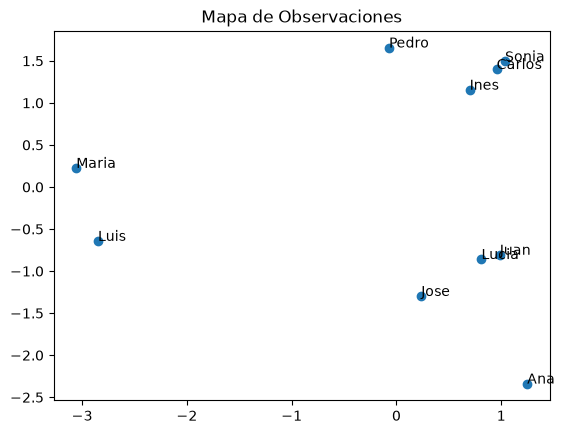

In [22]:
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]
z = df.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de Observaciones")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt,(x[i],y[i]))

In [23]:
componentes_2 = pd.DataFrame(data = modelo_pca.components_,
                             columns = df.columns,
                             index = ["PC1","PC2","PC3","PC4","PC5"])
componentes_2 = componentes_2.iloc[0:2,:]
componentes_2 = componentes_2.T
componentes_2

,PC1,PC2
Matematicas,0.440893,0.541975
Ciencias,0.269411,0.670171
Español,0.505459,-0.219216
Historia,0.534471,-0.407364
EdFisica,-0.438045,0.207685


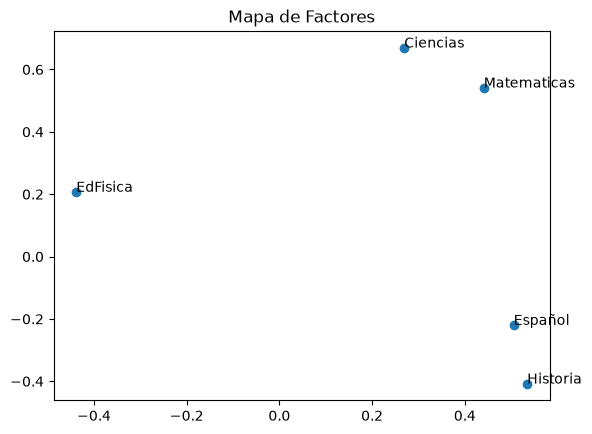

In [24]:
x = componentes_2.iloc[:,0]
y = componentes_2.iloc[:,1]
z = componentes_2.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de Factores")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt,(x[i],y[i]))

In [25]:
# Procedimiento para obtener la matriz estandarizada original
original = np.dot(modelo_pca.components_.T,proyecciones.T)
original = original.T
print(original)

[[ 0.23263076 -0.7529862   1.78848525  0.53369011  0.6333689 ]
 [ 0.78651352  1.14584856 -0.53899555 -0.84357469  0.00627098]
 [ 0.89729007  1.01489444  0.31849737  0.01721581  0.31981994]
 [-1.98290027 -0.7529862  -1.51898747 -0.84357469  1.26046682]
 [-0.87513476 -1.0803715   0.07349939  1.48055966 -2.50212069]
 [ 1.11884317  1.27680268 -0.0489996   0.01721581 -0.30727798]
 [-0.5428051  -0.81846326  0.56349535  0.87800631  0.13169056]
 [ 1.22961972  1.34227974 -0.29399757  0.01721581 -0.62082694]
 [-0.87513476 -1.0803715  -1.51898747 -2.13476044  1.07233744]
 [ 0.01107766 -0.29464677  1.1759903   0.87800631  0.00627098]]
